In [4]:
from pathlib import Path
import wave
import contextlib
import pandas as pd

# Base folder that contains class subfolders (asthma, copd, etc.)
base_data_dir = Path("data")

label_map = {
    "asthma": "Asthma",
    "copd": "COPD",
    "bronchial": "Bronchial",
    "pneumonia": "Pneumonia",
    "healthy": "Healthy",
}

rows = []

for wav_path in base_data_dir.rglob("*.wav"):
    folder_name = wav_path.parent.name.lower()
    label = label_map.get(folder_name, wav_path.parent.name)

    with contextlib.closing(wave.open(str(wav_path), "rb")) as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        duration_sec = n_frames / float(sample_rate) if sample_rate else 0.0

    # Relative path inside the stage after PUT data/*.wav @audio_stage
    file_path = str(wav_path.as_posix())

    rows.append(
        {
            "file_name": wav_path.name,
            "label": label,
            "duration_sec": duration_sec,
            "sample_rate": sample_rate,
            "file_path": file_path,
        }
    )

audio_metadata_df = pd.DataFrame(rows).sort_values(["label", "file_name"]).reset_index(drop=True)
audio_metadata_df.head(10)

,file_name,label,duration_sec,sample_rate,file_path
0,P10AsthmaIE_49.wav,Asthma,3.136,4000,data/asthma/P10AsthmaIE_49.wav
1,P10AsthmaIU_46.wav,Asthma,4.944,4000,data/asthma/P10AsthmaIU_46.wav
2,P10AsthmaIU_50.wav,Asthma,6.000,4000,data/asthma/P10AsthmaIU_50.wav
3,P10AsthmaRL_47.wav,Asthma,6.000,4000,data/asthma/P10AsthmaRL_47.wav
4,P10AsthmaRS_48.wav,Asthma,6.000,4000,data/asthma/P10AsthmaRS_48.wav
5,P11WheezingIE_53.wav,Asthma,6.000,4000,data/asthma/P11WheezingIE_53.wav
6,P11WheezingIU_54.wav,Asthma,6.000,4000,data/asthma/P11WheezingIU_54.wav
7,P11WheezingRL_51.wav,Asthma,5.952,4000,data/asthma/P11WheezingRL_51.wav
8,P11WheezingRL_55.wav,Asthma,5.536,4000,data/asthma/P11WheezingRL_55.wav
9,P11WheezingRS_52.wav,Asthma,6.000,4000,data/asthma/P11WheezingRS_52.wav


In [5]:
audio_metadata_df

,file_name,label,duration_sec,sample_rate,file_path
0,P10AsthmaIE_49.wav,Asthma,3.136000,4000,data/asthma/P10AsthmaIE_49.wav
1,P10AsthmaIU_46.wav,Asthma,4.944000,4000,data/asthma/P10AsthmaIU_46.wav
2,P10AsthmaIU_50.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaIU_50.wav
3,P10AsthmaRL_47.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRL_47.wav
4,P10AsthmaRS_48.wav,Asthma,6.000000,4000,data/asthma/P10AsthmaRS_48.wav
...,...,...,...,...,...
1206,P9Pneumonia63O.wav,Pneumonia,4.922154,44100,data/pneumonia/P9Pneumonia63O.wav
1207,P9Pneumonia67I.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia67I.wav
1208,P9Pneumonia73J.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia73J.wav
1209,P9Pneumonia74S.wav,Pneumonia,6.000000,44100,data/pneumonia/P9Pneumonia74S.wav


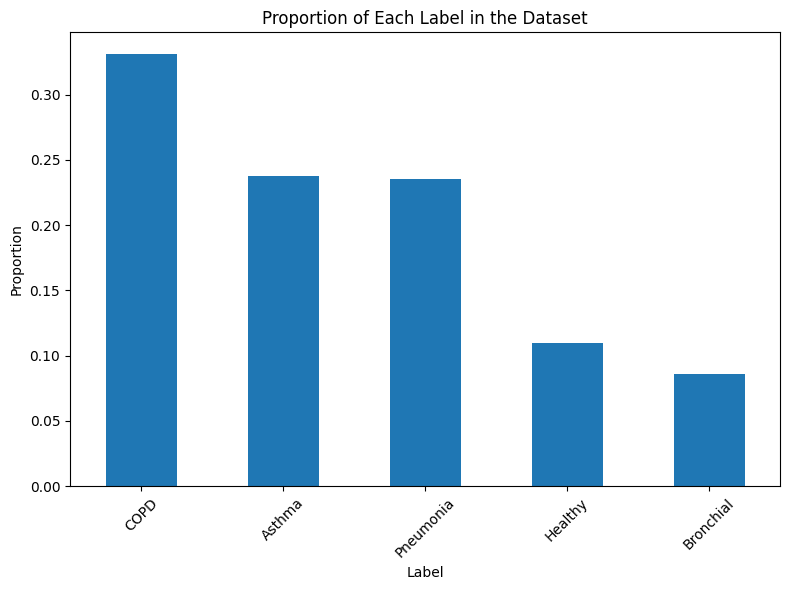

In [ ]:
label_counts = audio_metadata_df["label"].value_counts()
label_proportions = label_counts / label_counts.sum()
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
label_proportions.plot(kind="bar")
plt.title("Proportion of Each Label in the Dataset")
plt.xlabel("Label")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()